In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

file_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe(include='all'))
print("\nFirst 5 Rows:")
display(df.head())


Dataset Shape: (7043, 21)

Column Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Basic Statistics:
        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     3186-AJIEK   Male            NaN      No         No          NaN   
freq             1   3555    

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df = df.drop_duplicates()
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


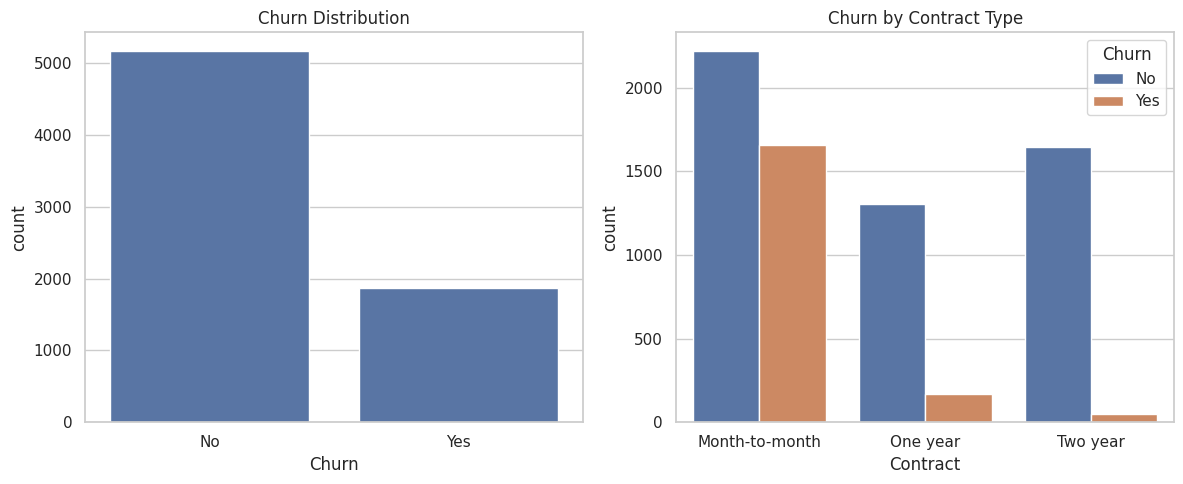

Churn Percentage Summary:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')

plt.tight_layout()
plt.show()

print("Churn Percentage Summary:")
print(df['Churn'].value_counts(normalize=True) * 100)


In [9]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print("Features Matrix Shape (X):", X.shape)
print("Target Vector Shape (y):", y.shape)


Features Matrix Shape (X): (7043, 30)
Target Vector Shape (y): (7043,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (4930, 30)
Testing samples: (2113, 30)


In [11]:
for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
    preds = model.predict(X_test)
    print(f"\n==================== {name} ====================")
    print("Accuracy Score:", accuracy_score(y_test, preds))
    print("\nClassification Report:\n", classification_report(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))



==================== Logistic Regression ====================
Accuracy Score: 0.8088026502602934

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1552
           1       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113

Confusion Matrix:
 [[1393  159]
 [ 245  316]]

==================== Random Forest ====================
Accuracy Score: 0.7898722195929957

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.63      0.50      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113

Confusion Matrix:
 [[1389  163]
 [ 281  280]]


In [12]:
sample_customer = X_test[:1]

prediction = rf_model.predict(sample_customer)
prediction_prob = rf_model.predict_proba(sample_customer)

print("Sample Input Visual Vector:\n", sample_customer)
print("\nPredicted Class:", "Churn (Yes)" if prediction == 1 else "No Churn (No)")
print("Confidence Probabilities [Stay, Leave]:", prediction_prob)


Sample Input Visual Vector:
 [[-0.43814715 -0.58721331  1.02841585 -0.24578582 -1.00528781 -0.96295739
  -0.65086184  0.33445908 -0.33445908 -0.85678685  1.12453737 -0.52587133
  -0.52587133  1.5698763  -0.52587133 -0.73200106 -0.52587133 -0.73265479
  -0.52587133 -0.64581257 -0.52587133  1.2409383  -0.52587133  1.24622683
  -0.51517027 -0.5647009   0.82967232 -0.52555704  1.40735673 -0.54312331]]

Predicted Class: Churn (Yes)
Confidence Probabilities [Stay, Leave]: [[0.4 0.6]]
